In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from utils_analysis import *
from collections import Counter
import pickle
import re
import seaborn as sns

# Retrieving Data

## Loading visit type

In [2]:
db = {}
with open('db.pkl', 'rb') as f:
    db = pickle.load(f)

Loading time: **6min**

## Loading results

In [3]:
prefix = "/home/infres/rapaport/results/FULL_2024_08_v2/focus/classes"
class_files = os.listdir(prefix)
df = pd.DataFrame()
for file in class_files:
    df = pd.concat([df, pd.read_csv(prefix + "/" + file, delimiter=";")])
    #df = pd.read_csv(file, delimiter=";")

Loading time: **40s**

## Filtering type
We only keep `git` origin and we remove all branches named `HEAD` because it is an alias.

In [4]:
df = df[(df['origin'].map(db) == 'git') & (df['branch_name'] != "HEAD")]

We stack together all branches `refs/pull/{digits}/head`

In [5]:
def normalize_branch_name(branch_name):
    pull_pattern = r'refs/pull/\d+/head'
    if re.match(pull_pattern, branch_name):
        return re.sub(r'(?<=refs/pull/)\d+(?=/head)', '{x}', branch_name)
    
    # Second pattern: normalize renovate branches
    renovate_pattern = r'refs/heads/renovate/.*'
    if re.match(renovate_pattern, branch_name):
        return re.sub(r'refs/heads/renovate/.*', 'refs/heads/renovate/{project}', branch_name)
    
    return branch_name
df['normalized_branch'] = df['branch_name'].apply(normalize_branch_name)

Filtering time: **6min**

## Retrieving stats

In [6]:
df["sub_categories"] = df["sub_categories"].fillna(",Other")
df["sub_categories"] = df["sub_categories"].str.replace(",", " ").str.strip()
alone, single, couple, triple = Counter(), Counter(), Counter(), Counter()
stats = [elt for elt in list(map(lambda categ: str(categ).split(" "), df["sub_categories"]))]
out_of = add_relations_v2(alone, single, couple, triple, stats)

Retrieving time: **35s**

## Saving Results

In [7]:
with open('res.pkl', 'wb') as f:
    pickle.dump(df, f)

Saving time: **15s**

## Loading Filtered Results
We can skip this phase if we did the previous ones or we can start here is `res.pkl` exists but still run the [Retrieving stats]() section.

In [8]:
df = pd.DataFrame()
with open('res.pkl', 'rb') as f:
    df = pickle.load(f)

Loading time: **12s**

# Analysis

### Amount of altered commits per main category

In [9]:
size = len(df)
meta_size = len(df.loc[df['main_category'] == 'META'])
print("nb META: ", meta_size)
dir_size = len(df.loc[df['main_category'] == 'DIR'])
print("nb DIR: ", dir_size)
issues = size - meta_size - dir_size
print("issues: ", issues)

nb META:  1160725
nb DIR:  7559360
issues:  0


- META: **1,160,725 commits**
- DIR: **7,559,360 commits**
- Issues: **0 commits**

### Quick pick at Loading Issues

In [10]:
li = df.loc[(df['main_category'] != 'META') & (df['main_category'] != 'DIR')]
li

,origin,snapshot_src,branch_name,missing_commit,snapshot_dst,first_difference,main_category,sub_categories,normalized_branch


## Test Repository
We check that our test repository is in the collected data in each category.

In [11]:
df.loc[df['origin']=="https://github.com/srapaport/missing_commits"]

,origin,snapshot_src,branch_name,missing_commit,snapshot_dst,first_difference,main_category,sub_categories,normalized_branch
54080,https://github.com/srapaport/missing_commits,swh:1:snp:9344bd2bc46dfc441ed0f07449dd3f171fc6...,refs/heads/main,swh:1:rev:76df8ca7ffae6244a463a280ab16e9a0e5bb...,swh:1:snp:30ac2ee7ff60cefc8ec5b71903b669904952...,swh:1:rev:fd7d413ed54e6fad86e44b11511225c23b0e...,META,Other,refs/heads/main
92621,https://github.com/srapaport/missing_commits,swh:1:snp:17db83d2223346ad7eaf9fd23f68a4c49f28...,refs/heads/main,swh:1:rev:3490b87918d649b65065caf66735a633f13a...,swh:1:snp:daa0c59835e446975bc44e2a419dcd188909...,swh:1:rev:29482f554f4c827dff469ebbf154c07b5d71...,META,Author,refs/heads/main
92941,https://github.com/srapaport/missing_commits,swh:1:snp:2041f0c4bbb2e1713a8e090b099456c9daff...,refs/heads/main,swh:1:rev:ade2d2d4856351f654516ad65da3ec69ab96...,swh:1:snp:3ffe9c416d794cc415220c65867e64f99693...,swh:1:rev:0135969d20841456afc0f6d7fc6ed4e55a26...,META,Message,refs/heads/main
99711,https://github.com/srapaport/missing_commits,swh:1:snp:97dd416171f4d0e624c3bc2eb22f98c7de63...,refs/heads/main,swh:1:rev:78273395091d3b35583884bd862b1b7fb736...,swh:1:snp:16896fa81da0d60645dc137f195b61e2fcac...,swh:1:rev:fe400ae5071269356cefeb92b60efaaa5477...,META,Message,refs/heads/main
123464,https://github.com/srapaport/missing_commits,swh:1:snp:7171271eacad37e770a2ba16ef9d60aa9412...,refs/heads/main,swh:1:rev:c4bef5c8a50202430ffe77b82aba5ca9c3be...,swh:1:snp:be6d8c4152fe4004af5a3b188513b982370d...,NaN,DIR,FileRemoved,refs/heads/main
124900,https://github.com/srapaport/missing_commits,swh:1:snp:fed196653ee63deec9156fbabe91b222605c...,refs/heads/main,swh:1:rev:153de376a93a0f67dae4e05164369da2c692...,swh:1:snp:8fc6e990ec745fa0b90c7ef9906e8984902f...,swh:1:rev:e83f39a4c83ca316494ea38d43ff3bbbaf41...,META,Other,refs/heads/main
152677,https://github.com/srapaport/missing_commits,swh:1:snp:3ee5f5fe2019c2da8b0292d9bdd75f548e99...,refs/heads/main,swh:1:rev:53be6956226811d8b740b1b70e5be378845e...,swh:1:snp:aae2c7b2392e8e2f51e009ae4ec9be2eb45e...,swh:1:rev:55bc91d546430631372d6f14c684f9abfb3d...,META,Date,refs/heads/main
194001,https://github.com/srapaport/missing_commits,swh:1:snp:98edabacefdf054df2b70bb1efb3411809de...,refs/heads/main,swh:1:rev:96540d7ee681c4992fec121217558485439d...,swh:1:snp:6ed853f3b77930031b0737f0f963e33ec5ee...,swh:1:rev:96540d7ee681c4992fec121217558485439d...,DIR,DifferentBranchName,refs/heads/main
206158,https://github.com/srapaport/missing_commits,swh:1:snp:9a60d1cd678413beef5ca05a3e294837b7d6...,refs/heads/main,swh:1:rev:13a742d20c3b433a581c0cf691adc1efa595...,swh:1:snp:d0a91beedc76bd8166ac32accc1aade35410...,swh:1:rev:95c2e38c6625a3c4d2cba11ca30e1483bdff...,META,CommitterDate,refs/heads/main
308568,https://github.com/srapaport/missing_commits,swh:1:snp:2a5ab681a4f818de5bfefec9de9bd2b6c998...,refs/heads/main,swh:1:rev:9bb7e2132d42b4ea2299906841ffae2921ec...,swh:1:snp:e44c273fb9ea32690bd922f189586d0ae691...,swh:1:rev:61439b82ee0334e06abb274b485972e0417b...,META,CommitterDate Message Date,refs/heads/main


## Graphic Representation

### Single
Representation of each category

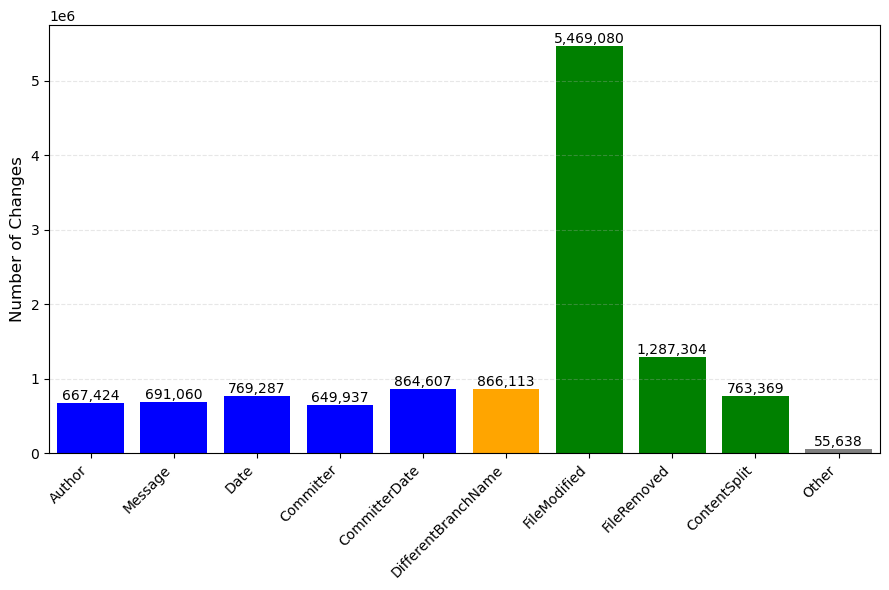

Counter({'FileModified': 5469080,
         'FileRemoved': 1287304,
         'ContentSplit': 763369,
         'DifferentBranchName': 866113,
         'Other': 55638,
         'Author': 667424,
         'Committer': 649937,
         'CommitterDate': 864607,
         'Date': 769287,
         'Message': 691060})

In [12]:
display_single(single)
single

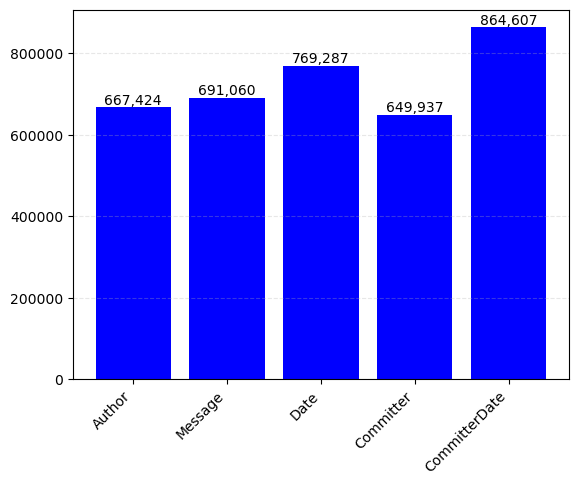

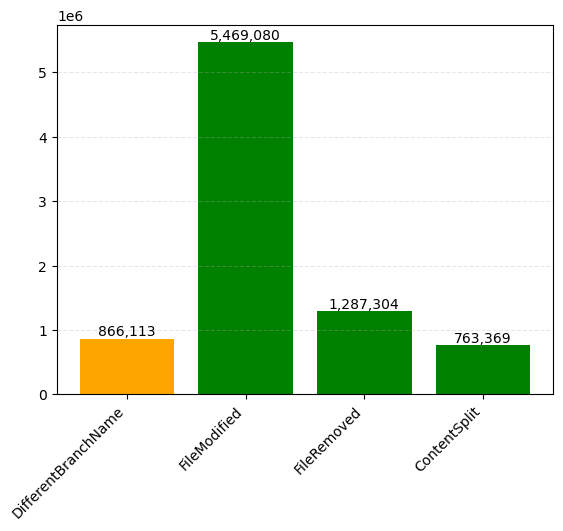

In [13]:
display_single_META(single)
display_single_DIR(single)

- FileModified: **5,469,080**
- FileRemoved: **1,287,304**
- DifferentBranchName: **866,113**
- CommitterDate: **864,607**
- Date: **769,287**
- ContentSplit: **763,369**
- Message: **691,060**
- Author: **667,424**
- Committer: **649,937**
- Other: **55,638**

## Crossing stats
Heatmap of couples and triples

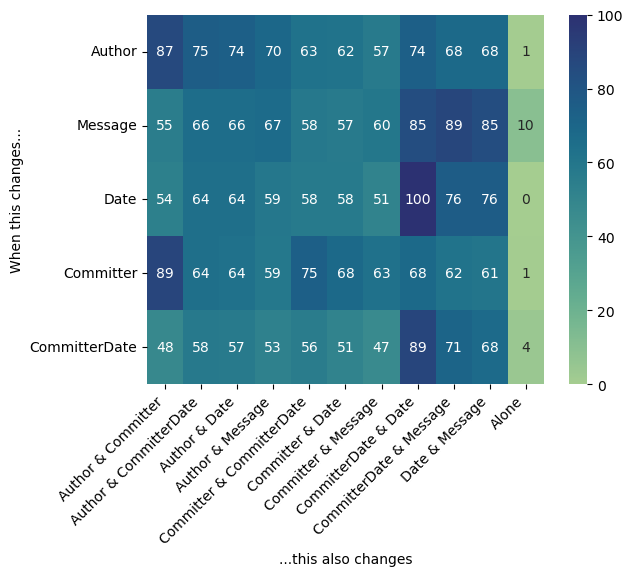

In [14]:
ht = heatmap_triple(triple, couple, single, alone, True)

### Triples under 25%

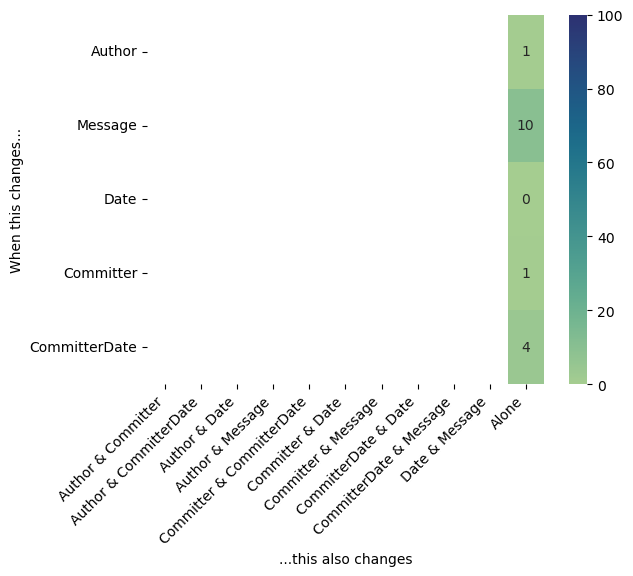

In [15]:
display_triple(ht, filter_percent(ht, 0, 25), with_mask_couple=False)

### Triples above 75%

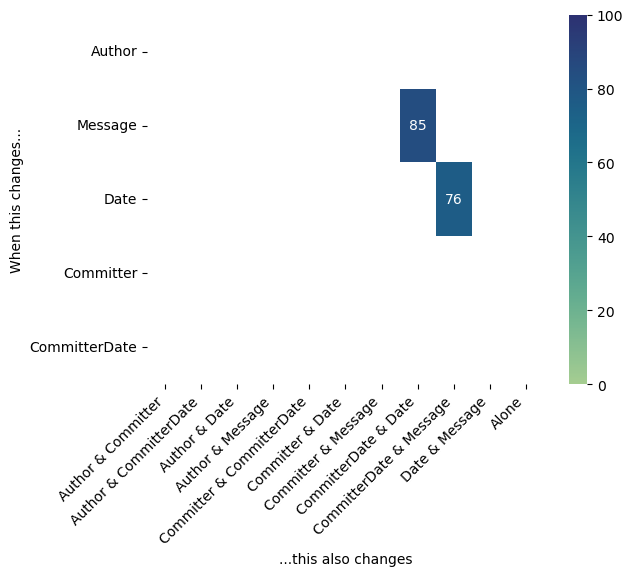

In [16]:
display_triple(ht, filter_percent(ht, 75, 100), with_mask_couple=True)

## Top Branches
Branches that are the most impacted

In [17]:
top_10_branches = df["branch_name"].value_counts().head(20)
print(top_10_branches)

refs/heads/master                          916883
refs/heads/gh-pages                        169624
refs/pull/1/head                            64115
refs/heads/main                             62525
refs/heads/renovate/configure               43898
refs/pull/2/head                            29859
refs/heads/develop                          29139
refs/heads/renovate/eslint-8.x              24252
refs/pull/3/head                            23400
refs/pull/4/head                            21359
refs/heads/pre-commit-ci-update-config      20710
refs/pull/5/head                            20139
refs/pull/6/head                            18996
refs/heads/dev                              18851
refs/heads/renovate/major-jest-monorepo     18793
refs/pull/7/head                            17943
refs/heads/renovate/babel-monorepo          17424
refs/pull/8/head                            17315
refs/pull/9/head                            17007
refs/pull/10/head                           16784


### Normalizing
We gather all pull branches together

In [18]:
top_10_branches_norm = df['normalized_branch'].value_counts().head(20)
print(top_10_branches_norm)

refs/pull/{x}/head                                   3276081
refs/heads/master                                     916883
refs/heads/renovate/{project}                         833524
refs/heads/gh-pages                                   169624
refs/heads/main                                        62525
refs/heads/develop                                     29139
refs/heads/pre-commit-ci-update-config                 20710
refs/heads/dev                                         18851
refs/heads/ubuntu/devel                                11927
refs/heads/applied/ubuntu/devel                        11866
refs/heads/wip                                         10317
refs/heads/output                                       9282
refs/heads/dependabot/npm_and_yarn/lodash-4.17.21       8276
refs/heads/next                                         7276
refs/merge-requests/1/merge                             7067
refs/heads/buster-staging                               6475
refs/heads/staging      

In [19]:
branch_df = top_10_branches_norm.reset_index()
branch_df.columns = ['branch', 'count']
total = len(df)
branch_df['percentage'] = (branch_df['count'] / total * 100).round(2)
print(branch_df)

                                               branch    count  percentage
0                                  refs/pull/{x}/head  3276081       37.57
1                                   refs/heads/master   916883       10.51
2                       refs/heads/renovate/{project}   833524        9.56
3                                 refs/heads/gh-pages   169624        1.95
4                                     refs/heads/main    62525        0.72
5                                  refs/heads/develop    29139        0.33
6              refs/heads/pre-commit-ci-update-config    20710        0.24
7                                      refs/heads/dev    18851        0.22
8                             refs/heads/ubuntu/devel    11927        0.14
9                     refs/heads/applied/ubuntu/devel    11866        0.14
10                                     refs/heads/wip    10317        0.12
11                                  refs/heads/output     9282        0.11
12  refs/heads/dependabot

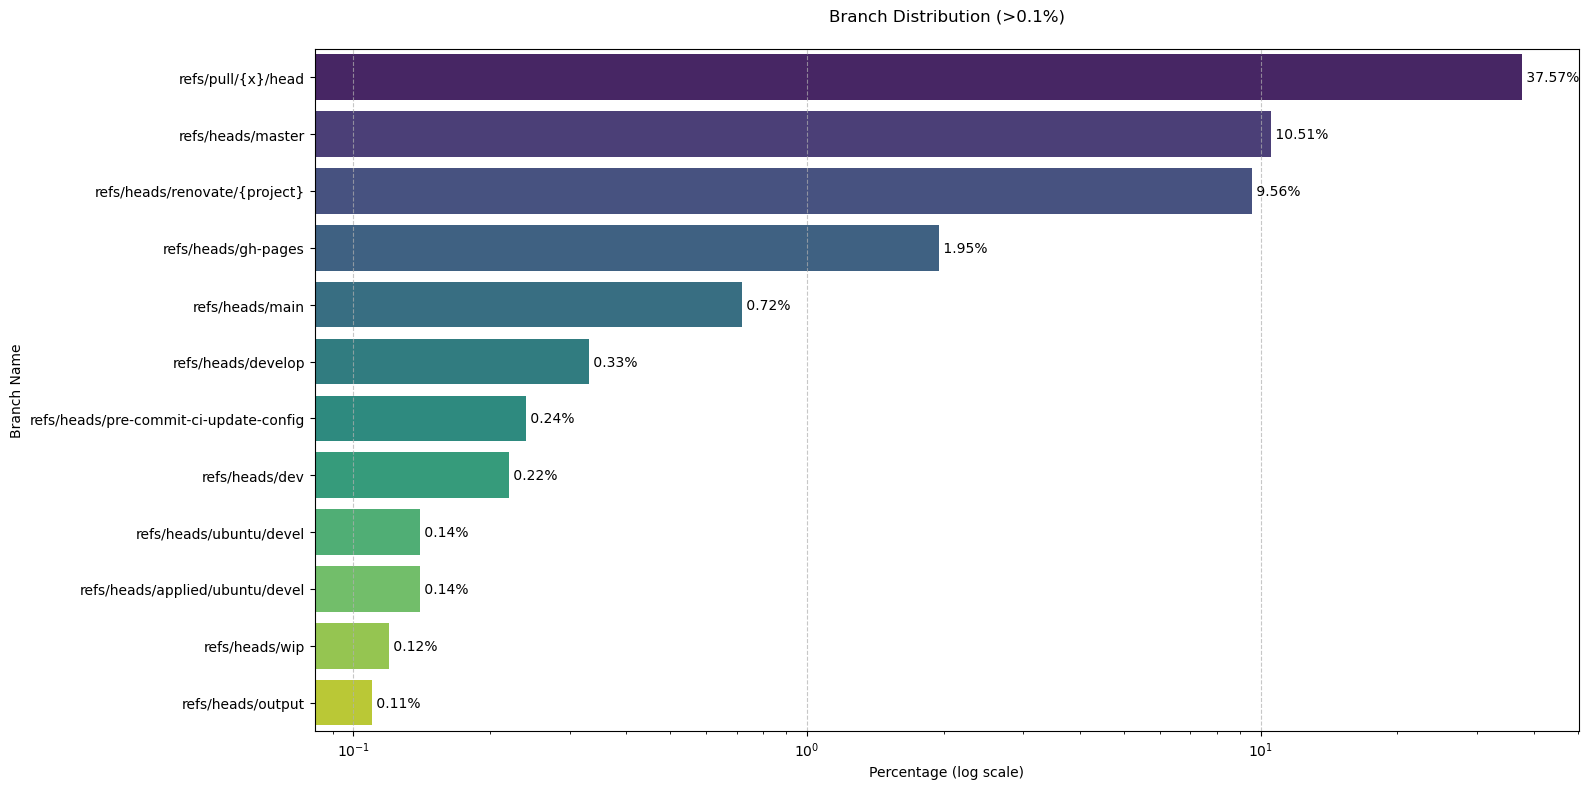

In [20]:
branch_stats = branch_df[branch_df['percentage'] > 0.1]

plt.figure(figsize=(16, 8))
sns.barplot(data=branch_stats, 
           y='branch', 
           x='percentage',
           palette='viridis',
           hue='branch',
           legend=False)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xscale('log')
for i, v in enumerate(branch_stats['percentage']):
    plt.text(v, i, f' {v:.2f}%', va='center')

plt.title('Branch Distribution (>0.1%)', pad=20)
plt.xlabel('Percentage (log scale)')
plt.ylabel('Branch Name')
plt.tight_layout()
plt.show()

In [21]:
df[df['branch_name'] == 'refs/heads/gh-pages']['origin'].value_counts().head(20)

https://github.com/coveo/react-vapor                       569
https://github.com/JPLachance/react-vapor                  154
https://github.com/stnolting/neorv32                       152
https://github.com/Koenkk/zigbee2mqtt.io                   147
https://github.com/mgerhardy/engine                        139
https://github.com/rust-lang/cargo                         136
https://github.com/JamesIves/github-pages-deploy-action    131
https://github.com/LCTT/TranslateProject                   130
https://github.com/nim-lang/Nim                            130
https://github.com/fsharp/FSharp.Compiler.Service          130
https://github.com/apereo/cas                              129
https://github.com/neovim/doc                              124
https://github.com/bevyengine/bevy                         124
https://github.com/OI-wiki/OI-wiki                         121
https://github.com/tgstation/tgstation                     120
https://github.com/Azure/azure-sdk-for-java            